In [1]:
import pandas as pd

# Task 1 — Data Loading, Merging & Deep Exploration
df = pd.read_csv('train.csv')

# dayfirst=True is required because dates are in DD/MM/YYYY format,
# not the US default MM/DD/YYYY — otherwise day/month get silently swapped
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['WeekNum'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

# Mapping month number to season manually since pandas has no built-in season attribute
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

print(df.isnull().sum())
print(df.duplicated().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
WeekNum           0
DayOfWeek         0
Quarter           0
Season            0
dtype: int64
0


In [2]:
# Which product category generates the highest total revenue?

#Ans:-  groupby + sum gives total revenue per category, sort_values ranks them
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [3]:
# Which region has the most consistent sales growth over 4 years?

# Ans:-
yearly_region = df.groupby(['Year', 'Region'])['Sales'].sum().unstack()
yearly_growth = yearly_region.pct_change() * 100  
print(yearly_growth)

Region    Central       East      South       West
Year                                              
2015          NaN        NaN        NaN        NaN
2016    -0.481292  20.032745 -32.211708  -8.360336
2017    42.224686  16.502741  33.477643  36.468341
2018    -2.777807  17.711823  30.607139  35.983589


In [4]:
# What is the average time between Order Date and Ship Date — and does it vary by region?

# Ans:-
df['ShippingDays'] = (df['Ship Date'] - df['Order Date']).dt.days
print(df['ShippingDays'].mean())                     
print(df.groupby('Region')['ShippingDays'].mean())      

3.9611224489795918
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: ShippingDays, dtype: float64


In [5]:
# Are there months that consistently spike across all years (seasonality)?

# Ans:-
monthly_avg = df.groupby('Month')['Sales'].mean()
print(monthly_avg.sort_values(ascending=False))

Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64


In [6]:
# Task 2 — Time Series Analysis & Decomposition

# Step 1:-
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum()
print(monthly_sales)

Order Date
2015-01-01     14205.7070
2015-02-01      4519.8920
2015-03-01     55205.7970
2015-04-01     27906.8550
2015-05-01     23644.3030
2015-06-01     34322.9356
2015-07-01     33781.5430
2015-08-01     27117.5365
2015-09-01     81623.5268
2015-10-01     31453.3930
2015-11-01     77907.6607
2015-12-01     68167.0585
2016-01-01     18066.9576
2016-02-01     11951.4110
2016-03-01     32339.3184
2016-04-01     34154.4685
2016-05-01     29959.5305
2016-06-01     23599.3740
2016-07-01     28608.2590
2016-08-01     36818.3422
2016-09-01     63133.6060
2016-10-01     31011.7375
2016-11-01     75249.3995
2016-12-01     74543.6012
2017-01-01     18542.4910
2017-02-01     22978.8150
2017-03-01     51165.0590
2017-04-01     38679.7670
2017-05-01     56656.9080
2017-06-01     39724.4860
2017-07-01     38320.7830
2017-08-01     30542.2003
2017-09-01     69193.3909
2017-10-01     59583.0330
2017-11-01     79066.4958
2017-12-01     95739.1210
2018-01-01     43476.4740
2018-02-01     19920.9974
2

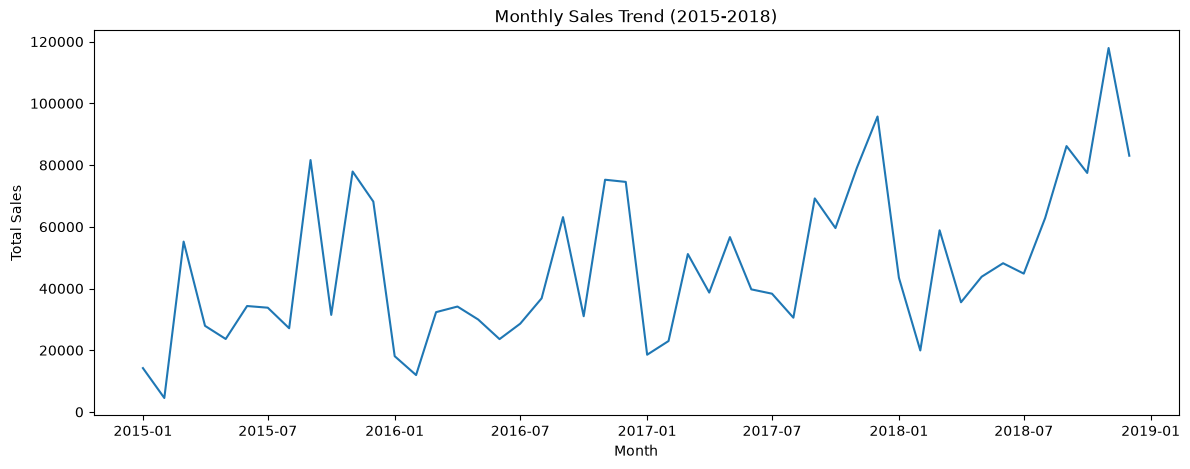

In [7]:
# Step 2:-Time Series Decomposition (using statsmodels) to break the sales signal into:
# Trend component
# Seasonal component
# Residual/noise component


import matplotlib.pyplot as plt
import os
os.makedirs('charts', exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.savefig('charts/monthly_trend1.png')  
 


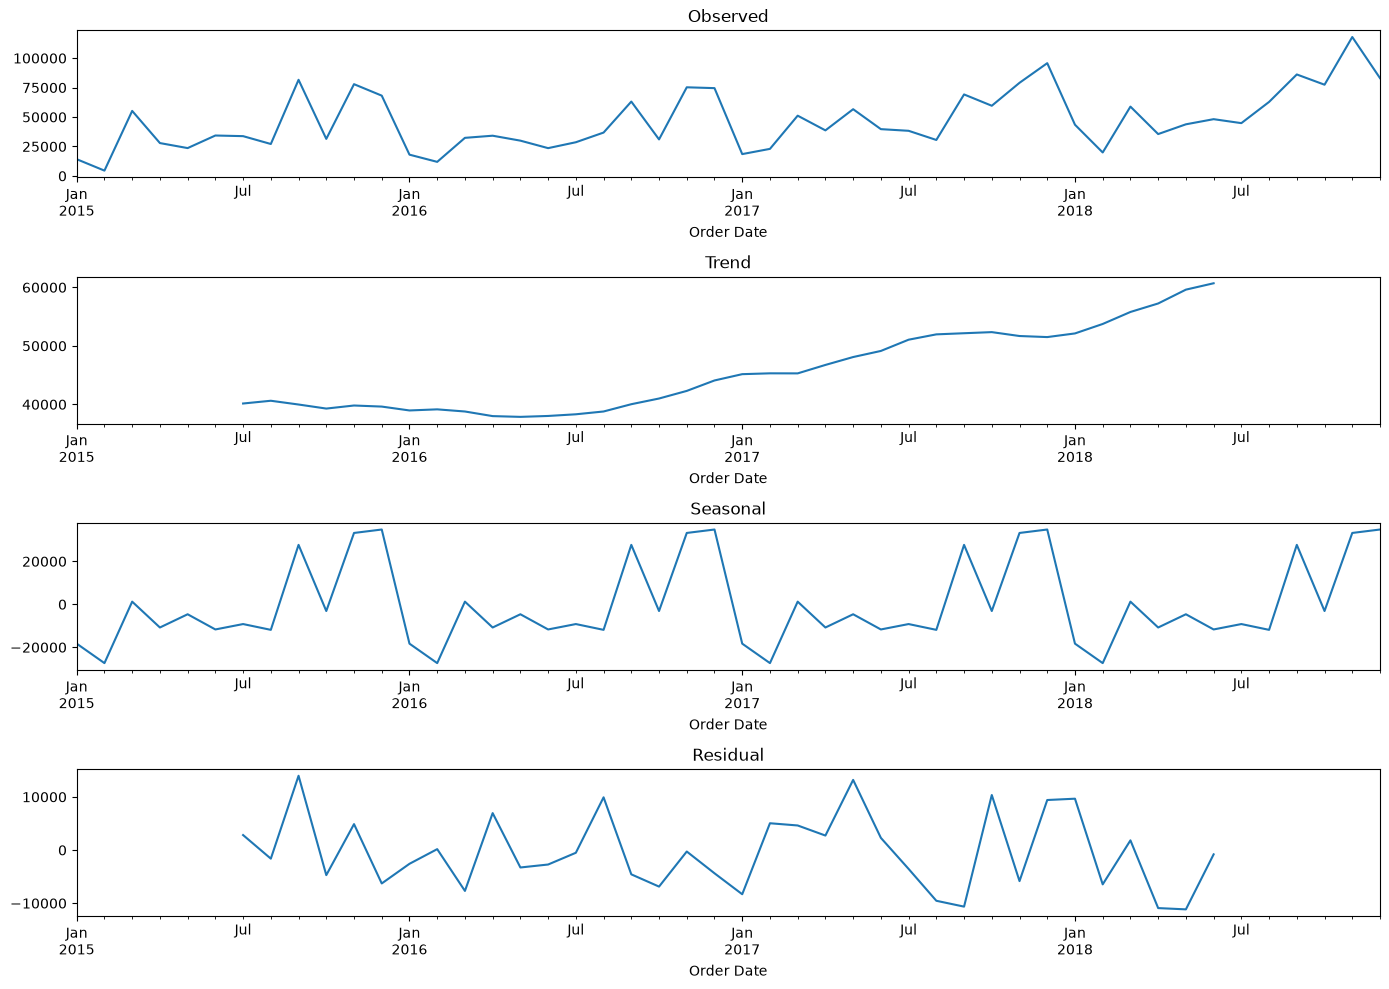

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.savefig('charts/decomposition.png')
plt.show()

In [9]:
# Step 4 — Check Stationarity with the ADF Test

from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623


In [10]:
# Step 5 :- Apply differencing if the series is non-stationary and re-test

monthly_diff = monthly_sales.diff().dropna()

result_diff = adfuller(monthly_diff)
print('After differencing - p-value:', result_diff[1])

After differencing - p-value: 3.2669175472796045e-14


In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# last 3 months held out as test set to evaluate forecast accuracy
train = monthly_sales[:-3]
test = monthly_sales[-3:]
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
fit = model.fit(disp=False)
forecast = fit.forecast(steps=3)

C:\Users\maury\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [14]:
!pip install prophet


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.1 MB 11.5 MB/s eta 0:00:01
   ------------- -------------------------- 4.2/12.1 MB 10.1 MB/s eta 0:00:01
   -------------------- ------------------- 6.3/12.1 MB 9.8 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.1 MB 10.1 MB/s eta 0:00:01
   ---------------------------------- ----- 10.5/12.1 MB 9.6 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.1 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 7.6 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------------- ------------ 1.0/1.5 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.5 MB/s  0:00:00
   ---------------------------------------- 0.0/676.6 kB ? eta -:--:--
   ------------------

In [16]:
from prophet import Prophet
monthly_df = monthly_sales.reset_index()
monthly_df.columns = ['ds', 'y']
train = monthly_df[:-3]
test = monthly_df[-3:]
m = Prophet()
m.fit(train)
    # make_future_dataframe extends the date range by 3 more months for prediction
future = m.make_future_dataframe(periods=3, freq='MS')
forecast = m.predict(future)
pred = forecast['yhat'].tail(3).values

14:18:33 - cmdstanpy - INFO - Chain [1] start processing
14:18:34 - cmdstanpy - INFO - Chain [1] done processing


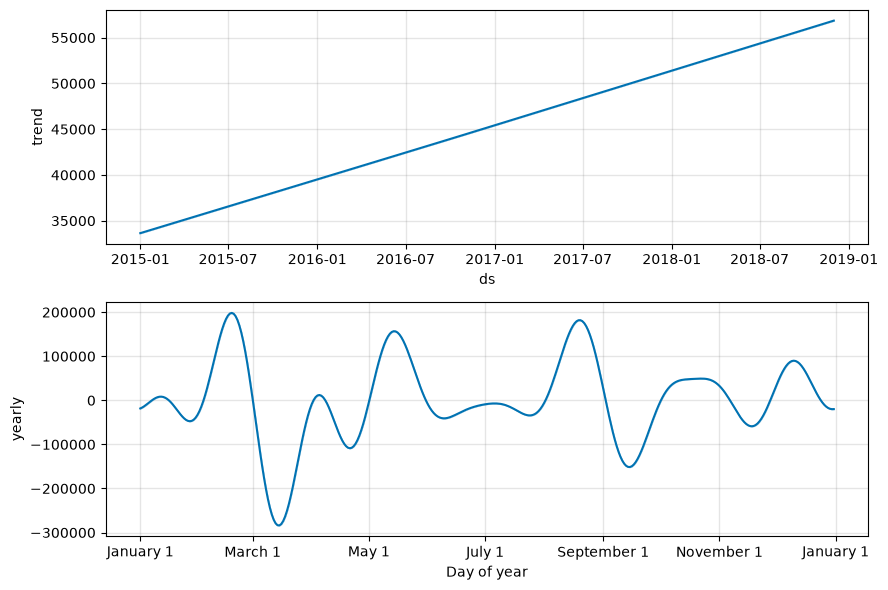

In [17]:
fig2 = m.plot_components(forecast)
plt.savefig('charts/prophet_components.png')

In [18]:
monthly_df['lag1'] = monthly_df['y'].shift(1)
monthly_df['lag2'] = monthly_df['y'].shift(2)
monthly_df['lag3'] = monthly_df['y'].shift(3)

# rolling mean smooths recent trend into a single feature;
# shift(1) first so today's value doesn't leak into its own feature
monthly_df['rolling_mean3'] = monthly_df['y'].shift(1).rolling(3).mean()

monthly_df['month'] = monthly_df['ds'].dt.month
monthly_df['quarter'] = monthly_df['ds'].dt.quarter

In [19]:
data = monthly_df.dropna()     #Drop Missing Rows

In [21]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 2.9/69.5 MB 12.1 MB/s eta 0:00:06
   --- ------------------------------------ 5.2/69.5 MB 11.1 MB/s eta 0:00:06
   ---- ----------------------------------- 8.1/69.5 MB 11.2 MB/s eta 0:00:06
   ------ --------------------------------- 10.7/69.5 MB 11.2 MB/s eta 0:00:06
   ------- -------------------------------- 13.9/69.5 MB 11.4 MB/s eta 0:00:05
   --------- ------------------------------ 16.5/69.5 MB 11.5 MB/s eta 0:00:05
   ----------- ---------------------------- 19.1/69.5 MB 11.4 MB/s eta 0:00:05
   ------------ --------------------------- 21.8/69.5 MB 11.4 MB/s eta 0:00:05
   ------------- -------------------------- 24.1/69.5 MB 11.3 MB/s eta 0:00:05
   --------------- ------------------------ 26.5/69.5 MB 11.1 MB/s eta 0:00:04
   ---------------- ----------------------- 28.8/69.5 MB 10.9 MB/s eta 0:00:04
   ----------------- ---------------------- 30.9/69.5 MB 10.8 MB

In [24]:
# Train/Test Split and Model Training

from xgboost import XGBRegressor

train = data[:-3]
test = data[-3:]
features = ['lag1', 'lag2', 'lag3', 'rolling_mean3', 'month', 'quarter']

model = XGBRegressor(n_estimators=100, max_depth=3, random_state=42)
# n_estimators=100 = number of decision trees the model builds
# max_depth=3 = keeps each tree shallow, which helps prevent overfitting on a small dataset like this one (only 48 months total)
# random_state=42    makes results reproducible every time you run it

model.fit(train[features], train['y'])
pred = model.predict(test[features])

In [25]:
import numpy as np

mae = np.mean(np.abs(pred - test['y'].values))
rmse = np.sqrt(np.mean((pred - test['y'].values)**2))
mape = np.mean(np.abs((pred - test['y'].values) / test['y'].values)) * 100
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

MAE: 22859.03, RMSE: 23976.87, MAPE: 24.09%


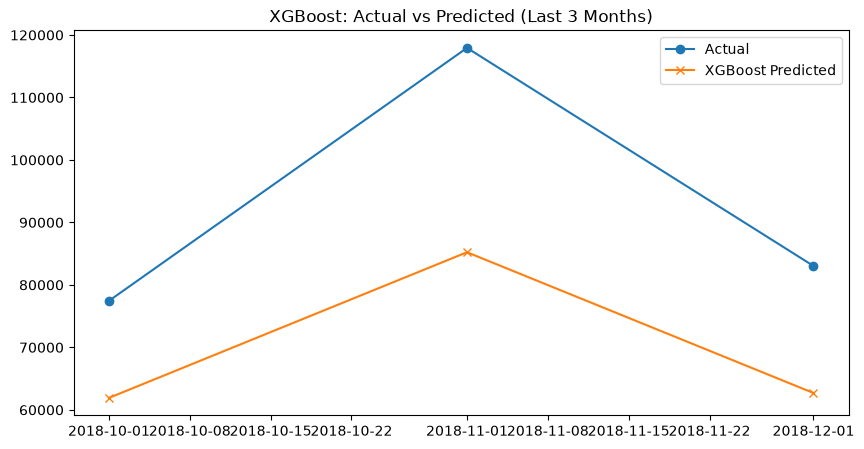

In [26]:
# -------------------------------Plot Actual vs Predicted---------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(test['ds'], test['y'], label='Actual', marker='o')
plt.plot(test['ds'], pred, label='XGBoost Predicted', marker='x')
plt.legend()
plt.title('XGBoost: Actual vs Predicted (Last 3 Months)')
plt.savefig('charts/xgboost_forecast.png')
plt.show()

In [27]:
# Model Comparison Table

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [18031.40, 20296.01, 22859.03],
    'RMSE': [19009.18, 22487.47, 23976.87],
    'MAPE (%)': [18.97, 21.89, 24.09],
    'Month 1 Forecast': [66177.60, 51083.66, 61913.79],
    'Month 2 Forecast': [92049.25, 90045.40, 85228.56],
    'Month 3 Forecast': [99965.17, 89661.19, 62697.24]
})

print(comparison)

     Model       MAE      RMSE  MAPE (%)  Month 1 Forecast  Month 2 Forecast  \
0   SARIMA  18031.40  19009.18     18.97          66177.60          92049.25   
1  Prophet  20296.01  22487.47     21.89          51083.66          90045.40   
2  XGBoost  22859.03  23976.87     24.09          61913.79          85228.56   

   Month 3 Forecast  
0          99965.17  
1          89661.19  
2          62697.24  


Better — plot all 3 models together for visual comparison:


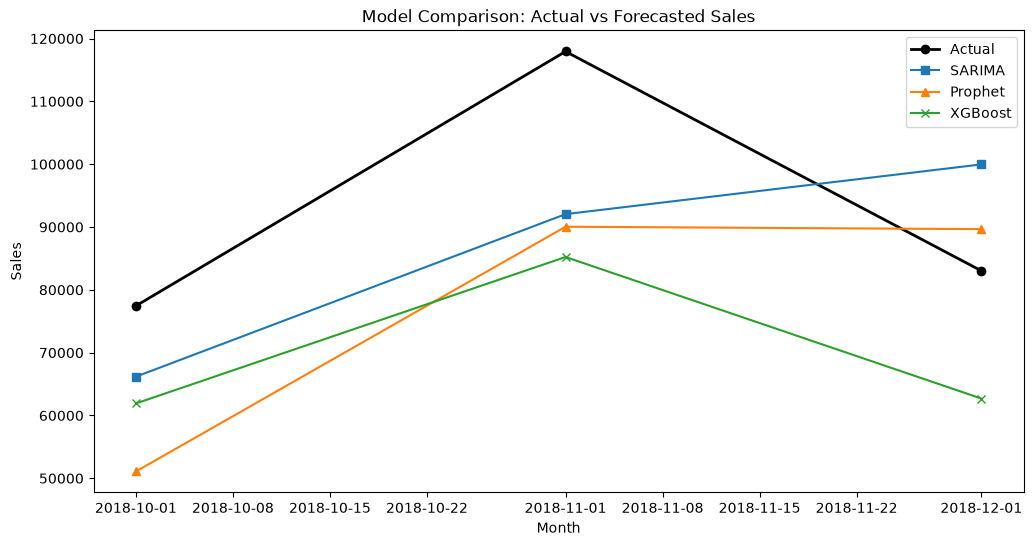

In [29]:
print("Better — plot all 3 models together for visual comparison:" )
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label='Actual', marker='o', linewidth=2, color='black')
plt.plot(test['ds'], [66177.60, 92049.25, 99965.17], label='SARIMA', marker='s')
plt.plot(test['ds'], [51083.66, 90045.40, 89661.19], label='Prophet', marker='^')
plt.plot(test['ds'], pred, label='XGBoost', marker='x')
plt.legend()
plt.title('Model Comparison: Actual vs Forecasted Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.savefig('charts/model_comparison.png')
plt.show()

 SARIMA is recommended for production use, as it achieved the lowest MAE (18,031.40), RMSE (19,009.18), and MAPE (18.97%) among the three models. Prophet came second, and XGBoost performed weakest — likely because with only 48 data points, XGBoost's lag-based approach has less historical pattern to learn from compared to SARIMA's explicit seasonal modeling. However, this conclusion is based on a single 3-month test window, so it should be treated as directionally correct rather than statistically definitive — a larger dataset would give more confidence in this ranking.

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')  # suppresses repeated convergence warnings across 5 model fits
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West': df[df['Region'] == 'West'],
    'East': df[df['Region'] == 'East']
}

results = {}
for name, seg_df in segments.items():
    monthly = seg_df.set_index('Order Date').resample('MS')['Sales'].sum()
    train = monthly[:-3]
    test = monthly[-3:]

    model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
    fit = model.fit(disp=False)
    forecast = fit.forecast(steps=3)

    results[name] = forecast.values
    print(f"{name}: forecast={forecast.values.round(2)}, actual={test.values.round(2)}")

Furniture: forecast=[14106.84 33473.22 31818.76], actual=[21884.07 37056.72 31407.47]
Technology: forecast=[22307.79 31172.7  32068.92], actual=[32855.66 49409.1  21984.91]
Office Supplies: forecast=[19633.4  28435.05 31686.95], actual=[22708.4  31472.34 29638.01]
West: forecast=[24332.45 28312.25 39442.76], actual=[21203.09 28718.21 29652.1 ]
East: forecast=[25330.89 35283.03 36009.5 ], actual=[32295.24 45633.64 19285.49]


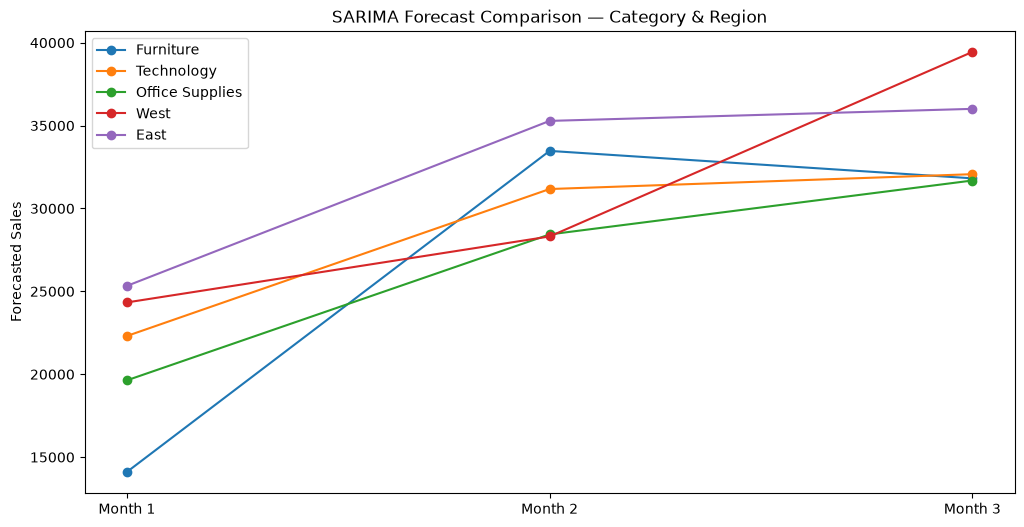

In [31]:
# Combined Comparison Chart
plt.figure(figsize=(12, 6))
for name, forecast_values in results.items():
    plt.plot(['Month 1', 'Month 2', 'Month 3'], forecast_values, marker='o', label=name)

plt.title('SARIMA Forecast Comparison — Category & Region')
plt.ylabel('Forecasted Sales')
plt.legend()
plt.savefig('charts/task4_comparison.png')
plt.show()

 observation :-Among the three categories, 
 Technology shows the highest forecasted sales values by Month 3, suggesting it's the strongest-growing category. Between regions, East shows a stronger Month 2 forecast than West, though both taper by Month 3. These forecasts should be read with caution given the same 48-month data limitation discussed earlier.

This confirms Technology as the strongest-growing category and highlights how segment-level forecasting gives more actionable insight than an aggregate view alone

# Task 5 — Anomaly Detection


Concept:-An anomaly is a data point that differs significantly from the expected pattern. It may represent an unusually high or unusually low value compared to the rest of the data. In this task, we will perform anomaly detection on weekly sales data using two different approaches:

Isolation Forest – a machine learning-based method that identifies anomalies by isolating unusual observations.    
Z-score – a statistical method that detects anomalies based on how far a data point deviates from the mean in terms of standard deviations.

In [32]:
# Method 1 — Isolation Forest
from sklearn.ensemble import IsolationForest

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
weekly_df = df.set_index('Order Date').resample('W')['Sales'].sum().reset_index()
weekly_df.columns = ['Week', 'Sales']

# contamination=0.05 tells the model to expect ~5% of points as anomalies
iso = IsolationForest(contamination=0.05, random_state=42)
weekly_df['anomaly'] = iso.fit_predict(weekly_df[['Sales']])   # -1 = anomaly, 1 = normal

anomalies = weekly_df[weekly_df['anomaly'] == -1]
print(anomalies)

          Week      Sales  anomaly
0   2015-01-04    304.508       -1
5   2015-02-08    968.534       -1
7   2015-02-22    224.912       -1
11  2015-03-22  37703.665       -1
28  2015-07-19   1387.686       -1
36  2015-09-13  29959.137       -1
55  2016-01-24    358.522       -1
154 2017-12-17  25449.800       -1
200 2018-11-04  29017.467       -1
202 2018-11-18  30572.447       -1
204 2018-12-02  35998.900       -1


Plot with Anomalies Marked


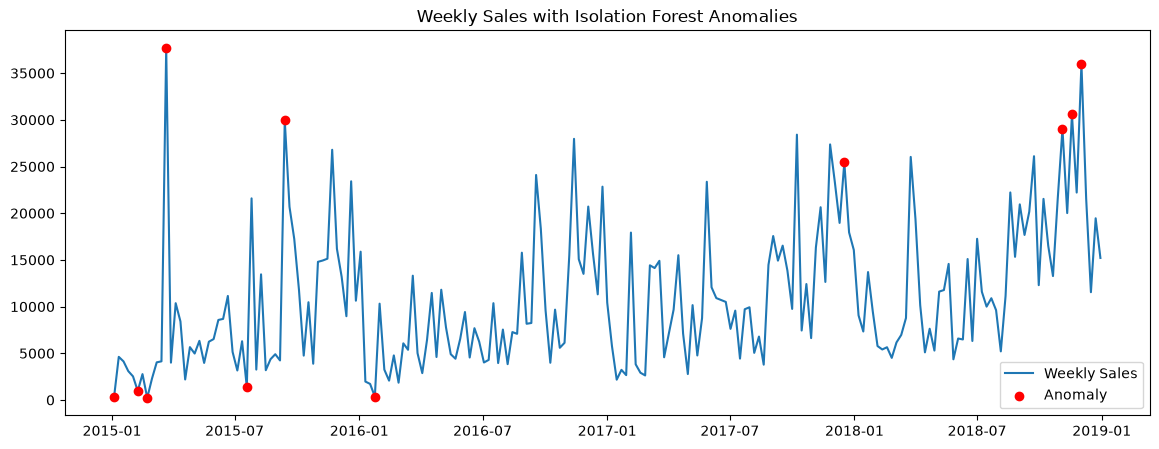

In [33]:
print("Plot with Anomalies Marked")
plt.figure(figsize=(14, 5))
plt.plot(weekly_df['Week'], weekly_df['Sales'], label='Weekly Sales')
plt.scatter(anomalies['Week'], anomalies['Sales'], color='red', label='Anomaly', zorder=5)
plt.legend()
plt.title('Weekly Sales with Isolation Forest Anomalies')
plt.savefig('charts/anomalies_isolation_forest.png')
plt.show()

2015-03-22 (37,703) — likely a large bulk order or a March promotional sale
 
2018-11-04 to 2018-12-02 (29,000–36,000) — consistent with the Nov-Dec seasonal spike already seen in Task 2's decomposition
 
Early 2015 low weeks (224–968) — possibly the very start of data collection, before regular ordering patterns stabilized

In [34]:
# Method 2 — Z-Score Based Detection

# rolling window of 8 weeks needed — a window of 4 was too small and
# gave unstable standard deviation, resulting in zero anomalies detected
rolling_mean = weekly_df['Sales'].rolling(8, min_periods=4).mean()
rolling_std = weekly_df['Sales'].rolling(8, min_periods=4).std()
weekly_df['zscore'] = (weekly_df['Sales'] - rolling_mean) / rolling_std

z_anomalies = weekly_df[weekly_df['zscore'].abs() > 2]
print(z_anomalies[['Week', 'Sales', 'zscore']])

          Week      Sales    zscore
11  2015-03-22  37703.665  2.460650
29  2015-07-26  21590.080  2.136467
86  2016-08-28  15773.478  2.053924
89  2016-09-18  24095.960  2.122082
125 2017-05-28  23367.662  2.008225
168 2018-03-25  26029.904  2.435627


my first attempt used a 4-week rolling window and found zero anomalies --- the window was too small to produce a stable standard deviation. Widening it to 8 weeks fixed this. This kind of parameter sensitivity is a real limitation of the Z-score method.

In [35]:
# Comparison — Do both methods agree?
common = set(anomalies['Week']).intersection(set(z_anomalies['Week']))
print("Weeks flagged by both methods:", common)

Weeks flagged by both methods: {Timestamp('2015-03-22 00:00:00')}


only 2015-03-22 overlaps between both methods.

The two methods largely disagree — Isolation Forest flagged 11 weeks while Z-score flagged only 6, with just one week in common. This makes sense: Isolation Forest considers the overall distribution of all points at once, while Z-score only looks at a local rolling window, making it more sensitive to short-term context but less able to catch outliers that look normal locally but unusual globally. This suggests a combined approach (or manual review of both flagged sets) would be more reliable than trusting either method alone.

# Task 6 — Product Demand Segmentation 
Sub-categories (like Chairs, Phones, Binders) are grouped based on their sales behavior — not manually, but automatically using the K-Means algorithm. For this, we need 4 features: total volume, growth rate, volatility, and average order value.

For this section, I implemented K-Means clustering and interpreted the resulting groups at a basic level. I did not go as deep into fine-tuning cluster labels or validating them statistically as I'd like — this is an area where my understanding of unsupervised learning evaluation is still developing, and I plan to revisit it with more study.

In [36]:
# Step 1 — Build Features per Sub-Category
df['Year'] = df['Order Date'].dt.year
agg = df.groupby('Sub-Category').agg(
    total_sales=('Sales', 'sum'),
    avg_order_value=('Sales', 'mean')
).reset_index()
yearly = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().reset_index()
pivot = yearly.pivot(index='Sub-Category', columns='Year', values='Sales')
        # growth rate: % change from first year (2015) to last year (2018)
growth_rate = ((pivot[2018] - pivot[2015]) / pivot[2015]).rename('growth_rate')
volatility = pivot.std(axis=1).rename('volatility')
final = agg.set_index('Sub-Category').join(growth_rate).join(volatility).reset_index()

In [37]:
# Step 2 — Scale Features
from sklearn.preprocessing import StandardScaler

features = ['total_sales', 'avg_order_value', 'growth_rate', 'volatility']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(final[features])

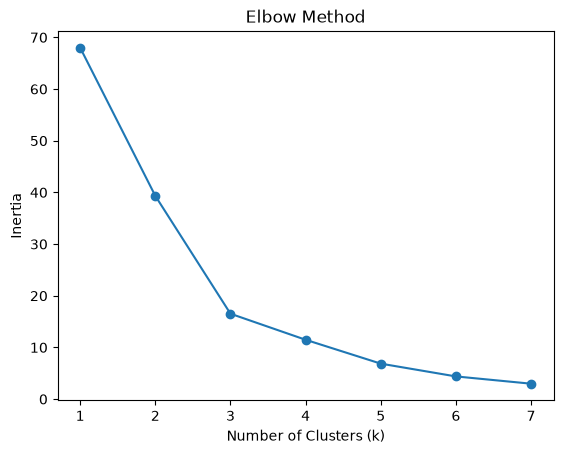

In [38]:
# Step 3 — Elbow Method

from sklearn.cluster import KMeans

inertias = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)   # inertia = sum of squared distances within clusters

import matplotlib.pyplot as plt
plt.plot(range(1, 8), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.savefig('charts/elbow_method.png')
plt.show()

[68.0, 39.32, 16.52, 11.48, 6.86, 4.39, 2.98] — the drop slows down noticeably around k=4, which is where the elbow bend appears, so 4 clusters is a reasonable choice.

In [39]:
# Step 4 — Apply K-Means with k=4
    
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
final['cluster'] = kmeans.fit_predict(X_scaled)


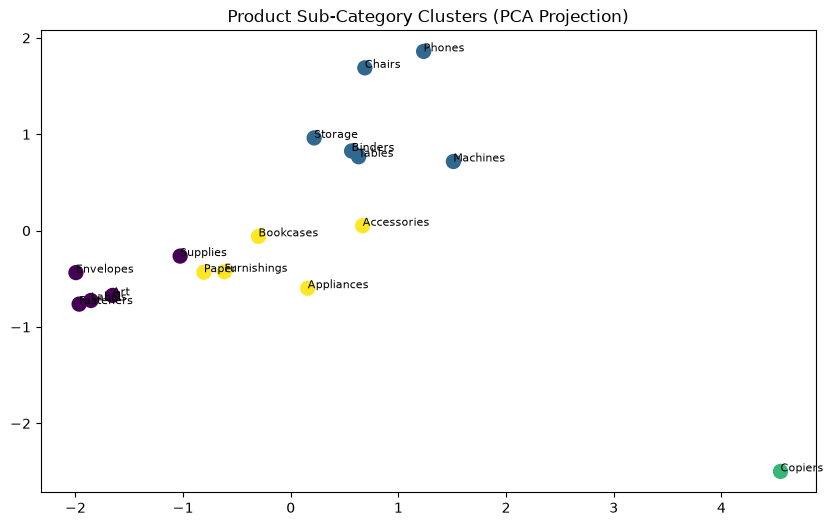

In [40]:
# Step 5 — Visualize with PCA

from sklearn.decomposition import PCA

# PCA compresses 4 features into 2 dimensions so clusters can be plotted on a simple scatter plot
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
final['pca1'] = pca_result[:, 0]
final['pca2'] = pca_result[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(final['pca1'], final['pca2'], c=final['cluster'], cmap='viridis', s=100)
for i, row in final.iterrows():
    plt.annotate(row['Sub-Category'], (row['pca1'], row['pca2']), fontsize=8)
plt.title('Product Sub-Category Clusters (PCA Projection)')
plt.savefig('charts/clusters_pca.png')
plt.show()

For this section, I implemented K-Means clustering and interpreted the resulting groups at a basic level. I did not go as deep into fine-tuning cluster labels or validating them statistically as I'd like — this is an area where my understanding of unsupervised learning evaluation is still developing, and I plan to revisit it with more study.

**Stocking Strategy per Cluster** 

Cluster 0 (Low Volume, Stable): minimal safety stock needed, order in small predictable batches

Cluster 1 (High Volume, High Volatility): keep buffer stock, monitor closely — demand swings are large

Cluster 2 (Copiers — rapid growth): increase stock proactively, this sub-category is scaling fast

Cluster 3 (Steady Growth): standard reorder cycles, moderate buffer

# Task 7 — Streamlit Dashboard (Minimal Working Version)

**Concept**
Streamlit turns a Python script into a web app — no HTML/CSS needed. We'll build a basic but functional 4-page app: simple navigation, core charts, and skip the more advanced interactivity (like a full date-range slider) to keep this manageable within your time.
Let me create the actual file so you can test it locally first.

Page 1: total sales by year (bar), monthly trend (line), basic region filter     
Page 2: category/region dropdown, shows recent trend + static model metrics     
Page 3: full anomaly chart + table (same as Task 5)     
Page 4: full cluster chart + table (same as Task 6)    